<a href="https://colab.research.google.com/github/Ifeoluwakareem/IFEOLUWA_ML/blob/main/Python_basics_01/tensors_fundamental/Neural_Network_Regression_with_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **What we're going to cover**
Specifically, we're going to go through doing the following with TensorFlow:

Architecture of a regression model
Input shapes and output shapes
X: features/data (inputs)
y: labels (outputs)
Creating custom data to view and fit
Steps in modelling
Creating a model
Compiling a model
Defining a loss function
Setting up an optimizer
Creating evaluation metrics
Fitting a model (getting it to find patterns in our data)
Evaluating a model
Visualizng the model ("visualize, visualize, visualize")
Looking at training curves
Compare predictions to ground truth (using our evaluation metrics)
Saving a model (so we can use it later)
Loading a model
Don't worry if none of these make sense now, we're going to go through

In [1]:
# Regression problem simply means predicting a number eg. Predict the selling price of houses given information about them (such as number of rooms, size, number of bathrooms).
import tensorflow as tf
print(tf.__version__) # check the version (should be 2.x+)

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

2.20.0
Notebook last run (end-to-end): 2026-06-28 17:02:08.178039


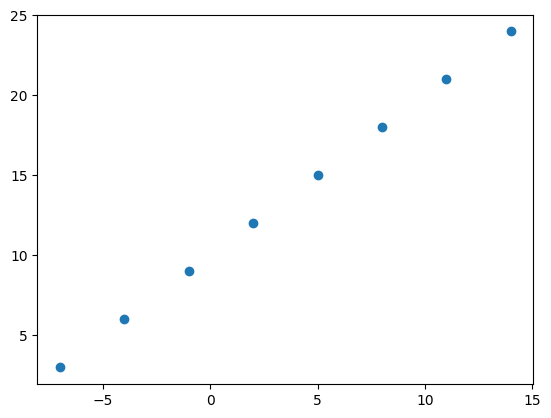

In [2]:
# Creating data to view and fit

import numpy as np
import matplotlib.pyplot as plt

## Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

# **Regression input shapes and output shapes**

The input shape is the shape of your data that goes into the model.
The output shape is the shape of your data you want to come out of your model.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

In [3]:
# Example input and output shapes of a regression model
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [4]:
house_info.shape

TensorShape([3])

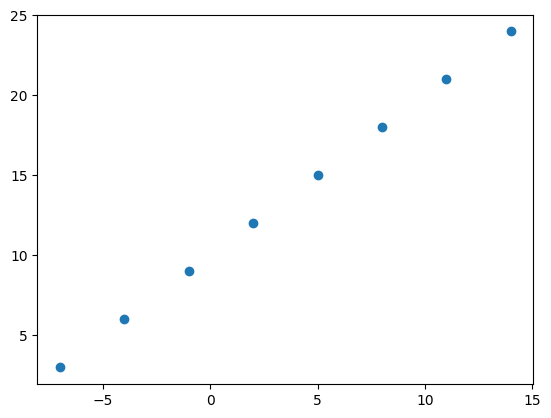

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create features (using tensors)
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels (using tensors)
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);



In [6]:
# Take a single example of X
input_shape = X[0].shape

# Take a single example of y
output_shape = y[0].shape

input_shape, output_shape # these are both scalars (no shape)

# From this it seems our inputs and outputs have no shape?
# How could that be?
# It's because no matter what kind of data we pass to our model, it's always going to take as input and return as output some kind of tensor.
# But in our case because of our dataset (only 2 small lists of numbers), we're looking at a special kind of tensor, more specifically a rank 0 tensor or a scalar.


(TensorShape([]), TensorShape([]))

In [7]:
# Let's take a look at the single examples invidually
X[0], y[0]


(<tf.Tensor: shape=(), dtype=float32, numpy=-7.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=3.0>)

If you were working on building a machine learning algorithm for predicting housing prices, your inputs may be number of bedrooms, number of bathrooms and number of garages, giving you an input shape of 3 (3 different features). And since you're trying to predict the price of the house, your output shape would be 1.

### **Steps in modelling with TensorFlow**
In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. Creating a model - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).
2. Compiling a model - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. Fitting a model - letting the model try to find patterns in the data (how does X get to y).

**Note**: If you're using TensorFlow 2.7.0+, the fit() function no longer upscales input data to go from (batch_size, ) to (batch_size, 1). To fix this, you'll need to expand the dimension of input data using tf.expand_dims(input_data, axis=-1).

In our case, this means instead of using model.fit(X, y, epochs=5), use model.fit(tf.expand_dims(X, axis=-1), y, epochs=5).

In [8]:
# Set random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # SGD is short for stochastic gradient descent
              metrics=["mae"])

# Fit the model
# model.fit(X, y, epochs=5) # this will break with TensorFlow 2.7.0+
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - loss: 7.6046 - mae: 7.6046
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4925 - mae: 7.4925
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.4869 - mae: 7.4869
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.4813 - mae: 7.4813
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 7.4756 - mae: 7.4756


In [9]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [10]:
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[29.269566]], dtype=float32)

In [11]:
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1)) # the right answer is 27.0 (y = X + 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[29.269566]], dtype=float32)

### **Improving a model**
How do you think you'd improve upon our current model?

If you guessed by tweaking some of the things we did above, you'd be correct.

To improve our model, we alter almost every part of the 3 steps we went through before.

1.  **Creating a model** - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose optimization function or perhaps change the learning rate of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from).

In [12]:
# Check out X and y are
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [13]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit model (this time we'll train for longer)
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100) # train for 100 epochs not 10

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - loss: 8.3696 - mae: 8.3696
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8.2371 - mae: 8.2371
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.1046 - mae: 8.1046
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.9721 - mae: 7.9721
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.8396 - mae: 7.8396
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.7071 - mae: 7.7071
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 7.5746 - mae: 7.5746
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 7.4475 - mae: 7.4475
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.4419 - mae: 7.4419
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.4362 - mae: 7.4362
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7.4306 - mae: 7.4306
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7.4250 - mae: 7.4250
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/s

In [14]:
# Try and predict what y would be if X was 17.0
# model.predict([17.0]) # the right answer is 27.0 (y = X + 10)


z = tf.constant([17.0])
# z1 = [17.0]
model.predict(z)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[29.85182]], dtype=float32)

In [15]:
import tensorflow as tf


name = "olawale       x"
print(name)

a = [17.0]   # python list
print( len(a), type(a))

# vector
# x -- [9,1,2]
# y -- [5,6,7]
# z -- [2,3,5]

# tensor rank
# [9,1,2]                                                   1D vector/ 1D tensor
# [ [9,1,2], [5,6,7] ]                                      2D vector/ 2D tensor
# [ [ [9,1,2], [5,6,7] ] , [ [9,1,2], [5,6,7] ]  ]         3D vector/ 3D tensor
# [    [ [ [9,1,2], [5,6,7] ] , [ [9,1,2], [5,6,7] ]  ],        [ [ [9,1,2], [5,6,7] ] , [ [9,1,2], [5,6,7] ]  ]         ]          4D vector/ 4D tensor
# shape --> shape(x,y,z)


b = tf.constant([9,1,2]) #-- [17.0], vector
print(type(b),  b.ndim, b.shape)




 #-- nested vectors = matrix

b2 = tf.constant([[9,1,2], [5,6,7] ]) #-- [17.0], vector
print(type(b2),  b2.ndim, b2.shape)

b3 = tf.constant([    [ [ [9,1,2], [5,6,7] ] , [ [9,1,2], [5,6,7] ]  ],        [ [ [9,1,2], [5,6,7] ] , [ [9,1,2], [5,6,7] ]  ]         ])
print(type(b3),  b3.ndim, b3.shape)


olawale       x
1 <class 'list'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 1 (3,)
<class 'tensorflow.python.framework.ops.EagerTensor'> 2 (2, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'> 4 (2, 2, 2, 3)


### **Evaluating a model**
A typical workflow you'll go through when building neural networks is:

    Build a model -> evaluate it -> build (tweak) a model -> evaulate it -> build (tweak) a model -> evaluate it...
    
The tweaking comes from maybe not building a model from scratch but adjusting an existing one.

### Visualize, visualize, visualize
When it comes to evaluation, you'll want to remember the words: "visualize, visualize, visualize."

This is because you're probably better looking at something (doing) than you are thinking about something.

It's a good idea to visualize:

**The data** - what data are you working with? What does it look like?

**The model itself** - what does the architecture look like? What are the different shapes?

**The training of a model** - how does a model perform while it learns?

**The predictions of a model** - how do the predictions of a model line up against the ground truth (the original labels)?

Let's start by visualizing the model.

But first, we'll create a little bit of a bigger dataset and a new model we can use (it'll be the same as before, but the more practice the better).



In [16]:
# Make a bigger dataset
X = np.arange(-100, 100, 4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [17]:
# Make labels for the dataset (adhering to the same pattern as before)
y = np.arange(-90, 110, 4)
y

# since y = X + 10, we could make the labels like so:

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])


### **Split data into training/test set**
One of the other most common and important steps in a machine learning project is creating a training and test set (and when required, a validation set).

Each set serves a specific purpose:

**Training set** - the model learns from this data, which is typically 70-80% of the total data available (like the course materials you study during the semester).
**Validation set** - the model gets tuned on this data, which is typically 10-15% of the total data available (like the practice exam you take before the final exam).
**Test set** - the model gets evaluated on this data to test what it has learned, it's typically 10-15% of the total data available (like the final exam you take at the end of the semester).

For now, we'll just use a training and test set, this means we'll have a dataset for our model to learn on as well as be evaluated on.

We can create them by splitting our X and y arrays.

🔑 **Note**: When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn on training data and then evaluate it on test data to get an indication of how well it **generalizes** to unseen examples.

In [18]:
# Check how many samples we have
len(X)


50

In [19]:
# Split data into train and test sets
X_train = X[:40] # first 40 examples (80% of data)
y_train = y[:40]

X_test = X[40:] # last 10 examples (20% of data)
y_test = y[40:]

len(X_train), len(X_test)


(40, 10)

### **Visualizing the data**
Now we've got our training and test data, it's a good idea to visualize it.

Let's plot it with some nice colours to differentiate what's what.

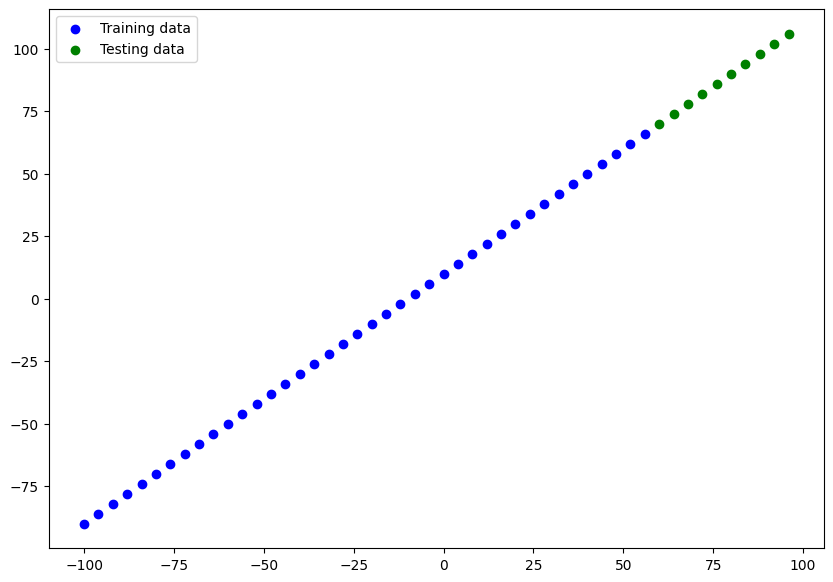

In [20]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(X_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();


In [21]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit model (same as above)
#model.fit(X_train, y_train, epochs=100) # commented out on purpose (not fitting it just yet)


### **Visualizing the model**

After you've built a model, you might want to take a look at it (especially if you haven't built many before).

You can take a look at the layers and shapes of your model by calling summary() on it.

🔑 Note: Visualizing a model is particularly helpful when you run into input and output shape mismatches.

In [22]:
# Doesn't work (model not fit/built)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1, input_shape=[1]) # define the input_shape to our model
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Fit the model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much

In [25]:
# Check the model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

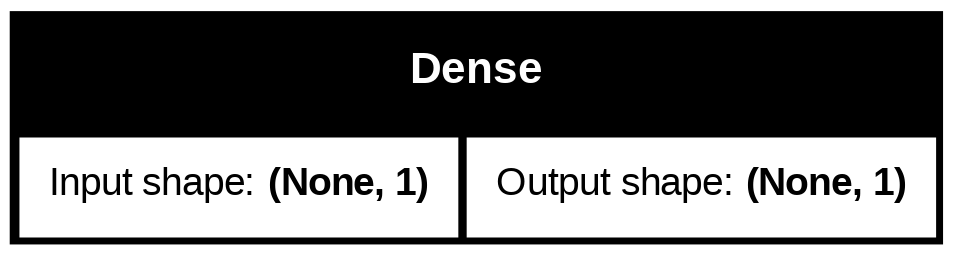

In [26]:
# Alongside summary, you can also view a 2D plot of the model using plot_model().

from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True)

### **Visualizing the predictions**
Now we've got a trained model, let's visualize some predictions.

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of **y_test** vs. **y_pred** (ground truth vs. predictions).

First, we'll make some predictions on the test data **(X_test)**, remember the model has never seen the test data.

In [27]:
# Make predictions
y_preds = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [28]:
# View the predictions
y_preds

# Okay, we get a list of numbers but how do these compare to the ground truth labels?
# Let's build a plotting function to find out.
# 🔑 Note: If you think you're going to be visualizing something a lot, it's a good idea to functionize it so you can use it later.

array([[ 68.632614],
       [ 73.11554 ],
       [ 77.598465],
       [ 82.08139 ],
       [ 86.564316],
       [ 91.04724 ],
       [ 95.53016 ],
       [100.013084],
       [104.49601 ],
       [108.978935]], dtype=float32)

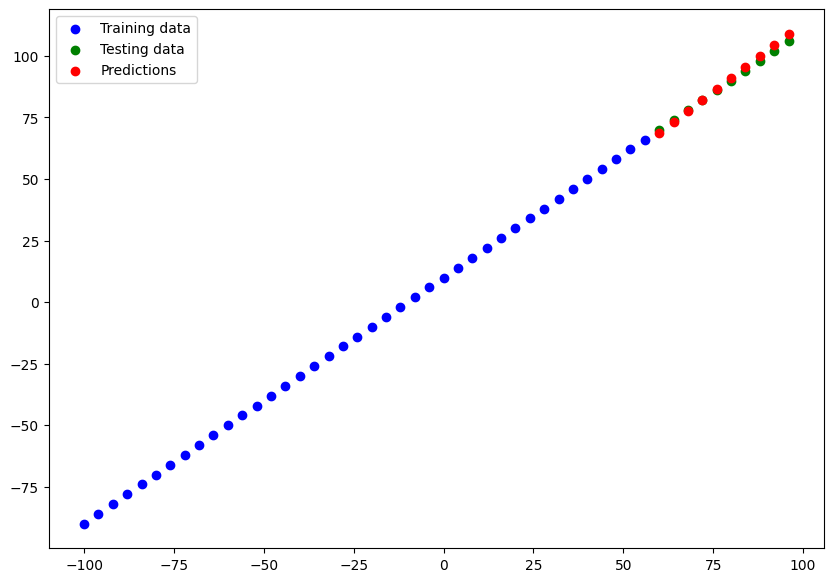

In [29]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();


plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_preds)

# From the plot we can see our predictions aren't totally outlandish but they definitely aren't anything special either.

### **Evaluating predictions**
Alongisde visualizations, evaulation metrics are your alternative best option forevaluating your model.

Depending on the problem you're working on, different models have different evaluation metrics.

Two of the main metrics used for regression problems are:

**Mean absolute error (MAE)** - the mean difference between each of the predictions.

**Mean squared error (MSE)** - the squared mean difference between of the predictions (use if larger errors are more detrimental than smaller errors).
The lower each of these values, the better.

You can also use model.evaluate() which will return the loss of the model as well as any metrics setup during the compile step.

In [30]:
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

# In our case, since we used MAE for the loss function as well as MAE for the metrics, model.evaulate() returns them both.
# TensorFlow also has built in functions for MSE and MAE.
# For many evaluation functions, the premise is the same: compare predictions to the ground truth labels.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 1.3365 - mae: 1.3365


[1.336451768875122, 1.336451768875122]

In [33]:
# Calculate the mean absolute error
# mae = tf.metrics.mean_absolute_error(y_true=y_test,
#                                    y_pred=y_preds)

mae = tf.keras.metrics.MeanAbsoluteError()
mae.update_state(y_test, y_preds)
print(mae.result().numpy())
mae


# 🔑 Note: If you're comparing two tensors, it's important to make sure they're the right shape(s) (you won't always have to manipulate the shapes, but always be on the look out, many errors are the result of mismatched tensors, especially mismatched input and output shapes).


1.3364518


<MeanAbsoluteError name=mean_absolute_error>


### **Running experiments to improve a model**
After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:

**Get more data** - get more examples for your model to train on (more opportunities to learn patterns).

**Make your model larger (use a more complex model)**  - this might come in the form of more layers or more hidden units in each layer.

**Train for longer** - give your model more of a chance to find the patterns in the data.

Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:

**model_1** - same as original model, 1 layer, trained for 100 epochs.

**model_2**- 2 layers, trained for 100 epochs.

**model_3** - 2 layers, trained for 500 epochs.

In [38]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 111.0818 - mae: 111.0818 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 76.3063 - mae: 76.3063
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 41.6306 - mae: 41.6306
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.7714 - mae: 11.7714
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 7.9734 - mae: 7.9734
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 10.9520 - mae: 10.9520
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.7162 - mae: 7.7162
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.0045 - mae: 12.0045
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.4036 - mae: 8.4036
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.0813 - mae: 9.0813
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.9044 - mae: 7.9044
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 10.8643 - mae: 10.8643
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


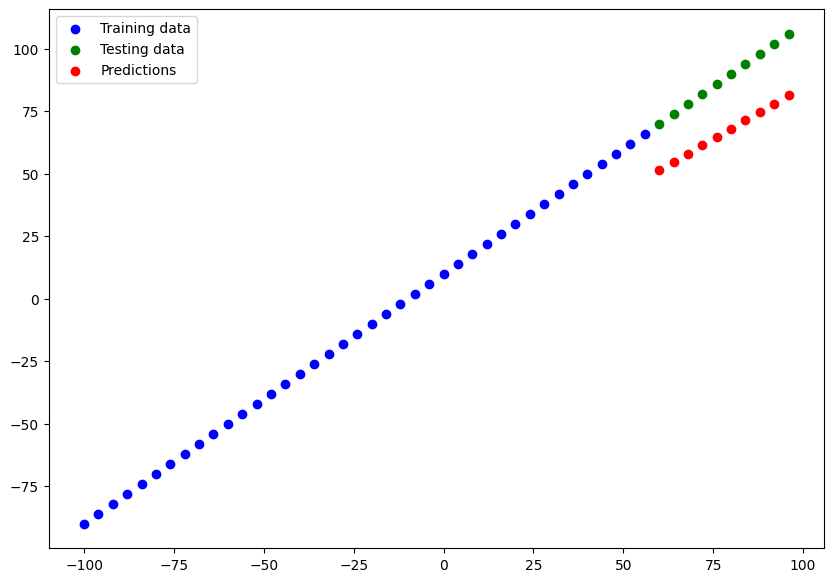

In [39]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [51]:
import tensorflow as tf

# Calculate model_1 metrics
mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_metric.update_state(y_test, y_preds_1.squeeze())
mae_1 = mae_metric.result().numpy()

mse_metric = tf.keras.metrics.MeanSquaredError()
mse_metric.update_state(y_test, y_preds_1.squeeze())
mse_1 = mse_metric.result().numpy()

In [53]:
# Display model_1 metrics
mae_1, mse_1

(np.float32(21.588654), np.float32(469.712))

### **Build model_2**

This time we'll add an extra dense layer (so now our model will have 2 layers) whilst keeping everything else the same.

In [47]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_1 and add an extra layer
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1) # add a second layer
])

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


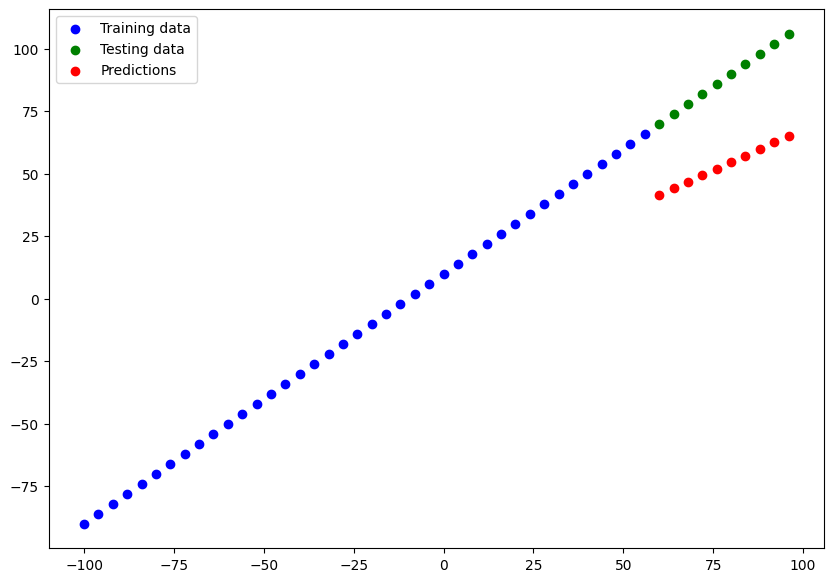

In [48]:
# Make and plot predictions for model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [52]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(24.853127), np.float32(656.22516))